## Implementing variation in ambiguity attitudes within a simulation

In [2]:
from importlib import reload
import mesa
from mesa.discrete_space import FixedAgent, OrthogonalMooreGrid
import pandas as pd
import numpy as np
from scipy.stats import bernoulli
import matplotlib.pyplot as plt
import seaborn as sns
import cognitive_functions as cf
from scipy.stats import t # For t-distribution
reload(cf)

<module 'cognitive_functions' from '/Users/brendanlam/Documents/GitHub/ABM-poverty-uncertainty/cognitive_functions.py'>

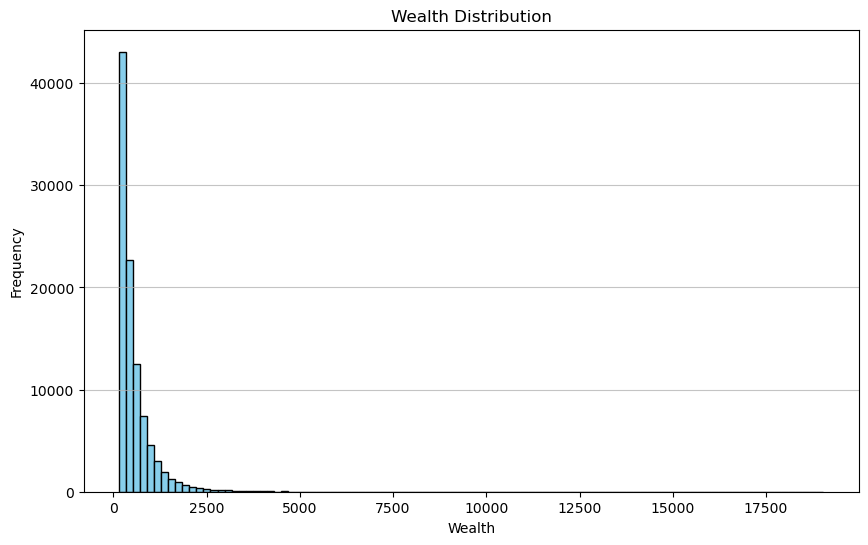

Gini Coefficient: 0.4057


In [93]:
all_wealth = np.random.pareto(a=5, size=100000) * 1600 + 150 # yields a gini coefficient of around 0.4

# Display histogram of wealth distribution
plt.figure(figsize=(10, 6))
plt.hist(all_wealth, bins=100, color='skyblue', edgecolor='black')
plt.title('Wealth Distribution')
plt.xlabel('Wealth')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# get gini coefficient
def gini_coefficient(arr):
    # Ensure the array is flattened and sorted
    arr = np.sort(arr.flatten())

    # Handle negative values by shifting the distribution to be non-negative
    if np.amin(arr) < 0:
        arr -= np.amin(arr)

    # Add a small constant to avoid division by zero if all values are zero
    arr += 1e-7

    n = arr.shape[0]
    index = np.arange(1, n + 1)

    # Gini coefficient formula based on the sorted array
    gini = ((np.sum((2 * index - n - 1) * arr)) / (n * np.sum(arr)))
    return gini
gini = gini_coefficient(all_wealth)
print(f"Gini Coefficient: {gini:.4f}")

In [94]:
class individual(FixedAgent):
    """An agent that chooses between two options based on the subjective value."""
    def __init__(self, model, lambd, gamma, reward_rb, reward_rf, cost_rb, min_start_wealth, p, beta_loc, beta_scale, alpha_loc, alpha_scale, num_neighbors):
        """ Create a new decision maker agent.
        Args:
            self: Object that stores characteristics of the agent.
            model: Reference to the model this agent belongs to.
            num_neighbors: Number of neighbors to consider for relative desperation.
            gamma: Utility parameter.
            reward_rb: Reward for rule breaking.
            reward_rf: Reward for following rules.
            cost_rb: Cost of rule breaking.
            min_start_wealth: The  minimum starting wealth of the agent.
            p: Probability of NOT being caught for rule-breaking.
            beta_loc: Mean optimism/pessimism of the distribution.
            beta_scale: Scale of the distribution for beta.
            alpha_loc: Mean likelihood sensitivity of the distribution.
            alpha_scale: Scale of the distribution for alpha.
            lambd: Desperation severity parameter.
            alpha: Likelihood sensitivity.
            desperate_state: State of relative desperation (0 = not desperate, 1 = desperate).
            radius: Radius for neighborhood search.
        """
        super().__init__(model)
        self.lambd = lambd
        self.gamma = gamma
        self.reward_rb = reward_rb
        self.reward_rf = reward_rf
        self.cost_rb = cost_rb
        self.p = p
        self.beta = (t.rvs(df=(model.width*model.height)-1, loc=beta_loc, scale=beta_scale, size=1)).item()
        self.alpha = (t.rvs(df=(model.width*model.height)-1, loc=alpha_loc, scale=alpha_scale, size=1)).item()

        self.wealth = np.random.pareto(a=5, size=1)[0] * 1600 + min_start_wealth  # Ensure wealth is above the minimum

        self.num_neighbors = num_neighbors
        self.desperate_state = 0  # Initialize desperate state to 0 (not desperate)
        self.decision = 0  # Initialize decision to 0 (follow rules)
        self.caught = False  # Initialize caught state to False
        self.income_rank = 0  # Initialize income rank to 0
        self.rb_choice = 0  # Initialize rule-breaking choice to 0 (follow rules)

    def relative_desperation(self):
        """Determine the relative desperation of the agent based on income rank."""
        # Get neighbors within the specified radius
        neighbors = self.model.grid.get_neighbors(self.pos, moore=True, include_center=False, radius=self.num_neighbors)

        # Get a vector of the wealth of the agents in the neighborhood
        neighbor_wealths = [neighbor.wealth for neighbor in neighbors] 
        # Count the number of neighbors with wealth lower than the agent's wealth
        num_poorer_neighbors = sum(1 for w in neighbor_wealths if w <= self.wealth)

        # Calculate the income rank of the agent in its neighborhood
        income_rank = cf.income_rank(i=num_poorer_neighbors, n=len(neighbors))
        self.income_rank = income_rank  # Store the income rank in the agent's attributes

        # Label the agent as desperate if their income rank is less than 0
        if income_rank < 0:
            self.desperate_state = 1  # Agent is relatively desperate
        else:
            self.desperate_state = 0  # Agent is not relatively desperate


    def compute_expected_utilities(self):
        """Choose an option based on subjective value. If agent is relatively desperate, use a different utility function."""
        if self.desperate_state == 1:
            # If the agent is relatively desperate, use a different utility function
            self.SV_rule_break = cf.SV_relative_desp_RB(
            gamma=self.gamma, starting_wealth=self.wealth, lambd=self.lambd, p=self.p, beta=self.beta, alpha=self.alpha, reward_rb=self.reward_rb, cost_rb=self.cost_rb)
        else:
            self.SV_rule_break = cf.SV_rule_break(gamma=self.gamma, reward_rb=self.reward_rb, cost_rb=self.cost_rb, p=self.p, beta=self.beta, alpha=self.alpha, starting_wealth=self.wealth)  # SV of rule breaking
        self.SV_follow_rules = cf.SV_follow_rules(reward_rf=self.reward_rf, starting_wealth=self.wealth, gamma=self.gamma) # SV of following rules

        # Compute the softmax probabilities
        probs = cf.softmax(self.SV_rule_break, self.SV_follow_rules)
        
        rb_choice = bernoulli.rvs(probs[0])  # Bernoulli trial for rule breaking choice
        if rb_choice==1:
            self.decision = 1 # breaks rules
        else:
            self.decision = 0 # follows rules
        return rb_choice
    
    def step(self):
        self.wealth_start = self.wealth
        self.relative_desperation() # Determine if the agent is relatively desperate
        self.compute_expected_utilities()

        # Update wealth based on decision
        if self.decision == 1: # breaks rules
            # If the agent chooses to break the rules and is NOT caught
            if bernoulli.rvs(self.p) == 1:
                self.caught = False
                self.wealth += self.reward_rb
            # If the agent chooses to break the rules and is caught
            else:
                self.caught = True
                self.wealth -= self.cost_rb
        else: 
            # If the agent chooses to follow the rules
            self.wealth += self.reward_rf
        # Deduct the cost of living (e.g., paying for food, rent, etc.)
        self.wealth -= 10

        # self.update_wealth() # Update the agent's wealth based on the choice made
        self.wealth_end = self.wealth


In [95]:
def crime_proportion(model):
    agent_crimes = [agent.decision for agent in model.agents]
    n = model.width * model.height  # Total number of agents in the grid
    proportion = (sum(agent_crimes) ) / n
    return proportion

def gini_coefficient(model):
    """Calculate the Gini coefficient for the wealth distribution of agents in the model."""
    agent_wealths = [agent.wealth for agent in model.agents]
    n = len(agent_wealths)
    if n == 0:
        return 0  # Avoid division by zero if there are no agents
    sorted_wealths = np.sort(agent_wealths)
    cumulative_wealth = np.cumsum(sorted_wealths)
    total_wealth = cumulative_wealth[-1]
    
    # Gini coefficient formula
    gini = (n + 1 - 2 * np.sum(cumulative_wealth) / total_wealth) / n
    return gini


In [96]:
from mesa import Model
from mesa.datacollection import DataCollector
from mesa.space import SingleGrid
import numpy as np

# from .agents import decision_maker

class rel_DMAP_model(Model):
    """A model with a number of decision makers."""
    def __init__(self, width, height, lambd, gamma, reward_rb, reward_rf, cost_rb, min_start_wealth, p, 
                 beta_loc, beta_scale, alpha_loc, alpha_scale, num_neighbors):
        super().__init__()
        self.width = width
        self.height = height
        self.grid = SingleGrid(width, height, torus=True)

        self.lambd = lambd
        self.gamma = gamma
        self.reward_rb = reward_rb
        self.reward_rf = reward_rf
        self.cost_rb = cost_rb
        self.p = p

        # self.num_neighbors = num_neighbors
        self.desperate_state = 0  # Initialize desperate state to 0 (not desperate)
        self.decision = 0  # Initialize decision to 0 (follow rules)
        self.caught = False  # Initialize caught state to False
        self.income_rank = 0  # Initialize income rank to 0
        self.rb_choice = 0  # Initialize rule-breaking choice to 0 (follow rules)

        # Create agents and place them on the grid
        for _, pos in self.grid.coord_iter():
            # Create a new agent at the current position
            agent = individual(
                model=self, lambd=self.lambd, gamma=self.gamma, reward_rb=self.reward_rb,
                reward_rf=self.reward_rf, cost_rb=self.cost_rb, min_start_wealth=min_start_wealth,
                p=self.p, beta_loc=beta_loc, beta_scale=beta_scale, alpha_loc=alpha_loc, 
                alpha_scale=alpha_scale, num_neighbors=num_neighbors)
            # Add the agent to the grid at the current position
            self.grid.place_agent(agent, pos)

    
        self.datacollector = mesa.DataCollector(
            model_reporters={"Proportion crime": crime_proportion},
            agent_reporters={ "Wealth Start": lambda a: getattr(a, "wealth_start", a.wealth), "Wealth End": 
                             lambda a: getattr(a, "wealth_end", a.wealth), "income rank":"income_rank", 
                             "desperate_state": "desperate_state", "uncert_aver": "beta", "uncert_insensitive": "alpha",
                             "Rule-breaking choice": "decision", "Caught": "caught", "SV_rule_break": "SV_rule_break", 
                             "SV_follow_rules": "SV_follow_rules"}
            )
        self.running = True
        self.datacollector.collect(self)
    
    def step(self):
        # self.datacollector.collect(self)
        self.agents.do("step")
        self.datacollector.collect(self)
        

    

        


In [165]:
# Run the model for a number of steps
test_model = rel_DMAP_model(lambd=0.5, gamma=0.3, reward_rb=50, reward_rf=25, cost_rb=300, 
                            beta_loc=0.1, beta_scale=0.5, alpha_loc=0.4, alpha_scale=0.5, 
                            min_start_wealth=150, p=0.9, width=40, height=40, num_neighbors=20)
for _ in range(500):
    test_model.step()

model_df = test_model.datacollector.get_model_vars_dataframe()
agent_df = test_model.datacollector.get_agent_vars_dataframe()

In [166]:
agent_df = test_model.datacollector.get_agent_vars_dataframe()
agent_df = agent_df.reset_index()
# remove time step 0 from agent_df
agent_df = agent_df[agent_df['Step'] > 0]
agent_df.head()

,Step,AgentID,Wealth Start,Wealth End,income rank,desperate_state,uncert_aver,uncert_insensitive,Rule-breaking choice,Caught,SV_rule_break,SV_follow_rules
1600,1,1,177.733031,192.733031,0.081352,0,0.071383,-0.165289,0,False,4.178758,4.921272
1601,1,2,197.330614,237.330614,0.131414,0,-0.498119,1.320494,1,False,5.462456,5.059409
1602,1,3,436.517590,451.517590,0.563830,0,-0.528537,0.021870,0,False,7.725755,6.298781
1603,1,4,2174.187278,1864.187278,0.986233,0,0.063953,0.578137,1,True,10.087323,10.061869
1604,1,5,541.998097,556.998097,0.663329,0,-0.711762,0.911270,0,False,6.940473,6.699995


In [29]:
agent_df.shape

(320000, 12)

## Data Visualization and Analysis

Text(0.5, 1.0, 'Wealth Over Time by Agent')

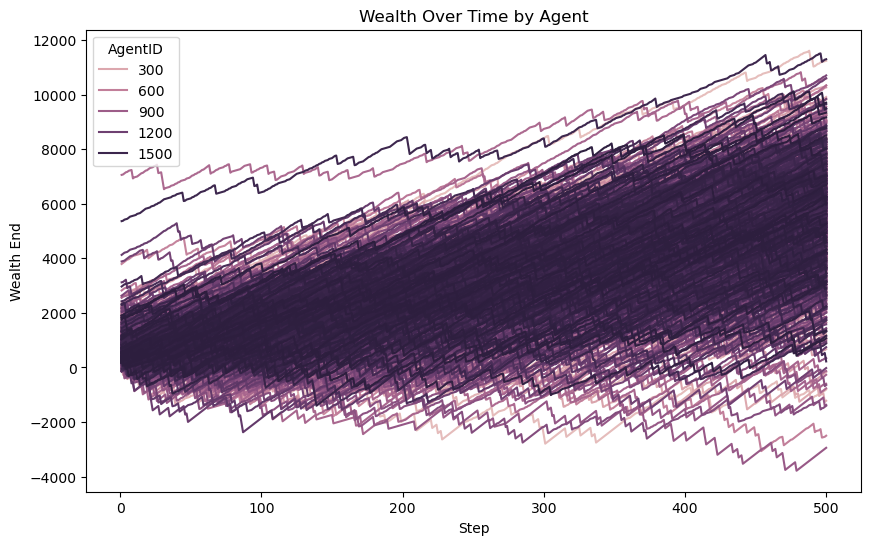

In [167]:
# Plot each agent's wealth over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=agent_df, x="Step", y="Wealth End", hue="AgentID")
plt.title("Wealth Over Time by Agent")

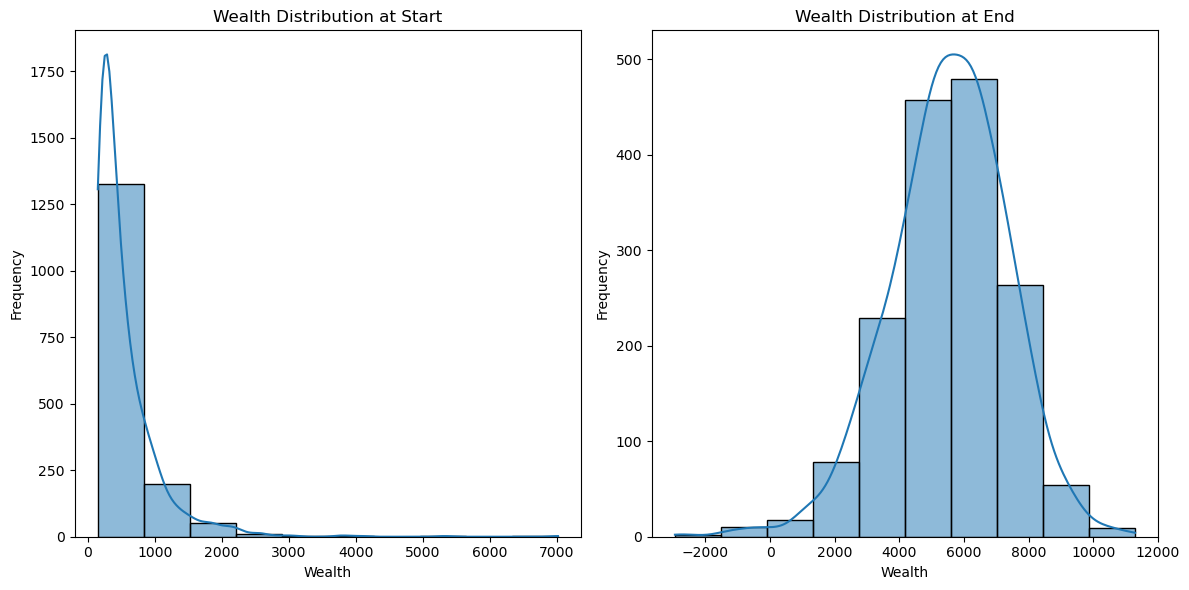

In [168]:
# Plot the wealth distribution at the start and end of the simulation
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(agent_df[agent_df['Step'] == 1]['Wealth Start'], bins=10, kde=True)
plt.title("Wealth Distribution at Start")
plt.xlabel("Wealth")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
sns.histplot(agent_df[agent_df['Step'] == agent_df['Step'].max()]['Wealth End'], bins=10, kde=True)
plt.title("Wealth Distribution at End")
plt.xlabel("Wealth")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

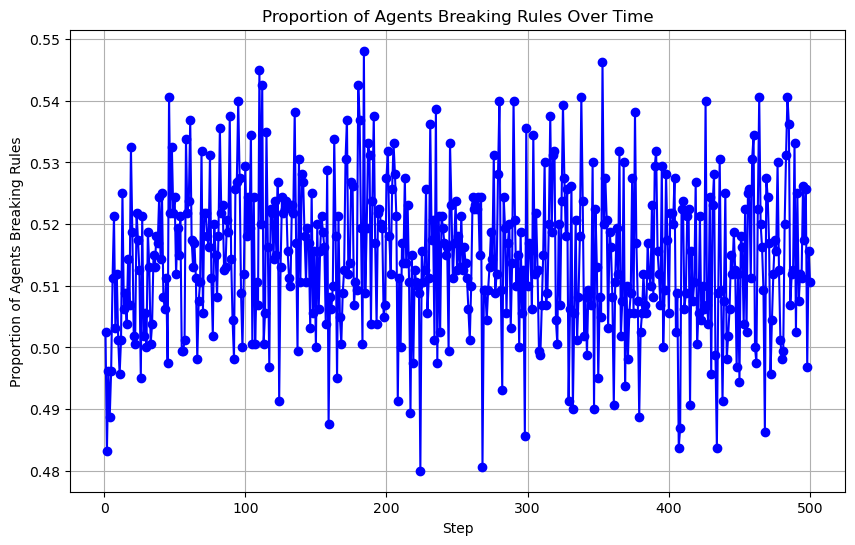

In [169]:
# Make the index its own column
model_df = model_df.reset_index()
# Look at the proportion of agents who break the rules over time
proportion_crime = model_df
# remove the first row (time step 0)
proportion_crime = proportion_crime[proportion_crime['index'] > 0]
proportion_crime = proportion_crime.rename(columns={"Step": "index"})
# Plot the proportion of agents who break the rules over time
plt.figure(figsize=(10, 6))
plt.plot(proportion_crime["index"], proportion_crime["Proportion crime"], marker='o', linestyle='-', color='b')
plt.title("Proportion of Agents Breaking Rules Over Time")
plt.xlabel("Step")
plt.ylabel("Proportion of Agents Breaking Rules")
plt.grid()
plt.show()


In [102]:
# Save the agent DataFrame to a CSV file
agent_df.to_csv("agent_data.csv", index=False)
model_df.to_csv("model_data.csv", index=False)

In [170]:
last_time_step_df = agent_df[agent_df['Step'] == agent_df['Step'].max()]['Wealth End']
# get gini coefficient for the last time step
def gini_coef(wealth):
    """Calculate the Gini coefficient for the wealth distribution of agents in the model."""
    n = len(wealth)
    if n == 0:
        return 0  # Avoid division by zero if there are no agents
    sorted_wealth = np.sort(wealth)
    cumulative_wealth = np.cumsum(sorted_wealth)
    total_wealth = cumulative_wealth[-1]
    
    # Gini coefficient formula
    gini = (n + 1 - 2 * np.sum(cumulative_wealth) / total_wealth) / n
    return gini
gini = gini_coef(last_time_step_df)

# First time step Gini coefficient
first_time_step_df = agent_df[agent_df['Step'] == 1]['Wealth Start']
first_gini = gini_coef(first_time_step_df)
print(f"Gini coefficient at the first time step: {first_gini}")
# Last time step Gini coefficient
print(f"Gini coefficient at the last time step: {gini}")


Gini coefficient at the first time step: 0.4013085810581092
Gini coefficient at the last time step: 0.18432946572141176


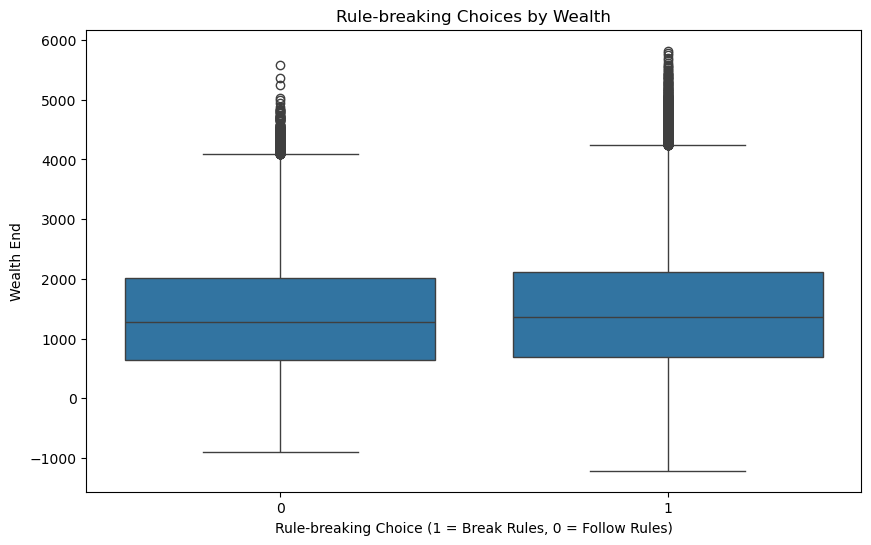

In [25]:
# Boxplot of rule-breaking choices by wealth
plt.figure(figsize=(10, 6))
sns.boxplot(data=agent_df, x="Rule-breaking choice", y="Wealth End")
plt.title("Rule-breaking Choices by Wealth")
plt.xlabel("Rule-breaking Choice (1 = Break Rules, 0 = Follow Rules)")
plt.ylabel("Wealth End")
plt.show()

In [ ]:
# (ambiguity aversion)/beta mean: 0.12; median: 0.09, SD: 0.41, min: -0.97 max: 0.97
# (a-insensitivity)/alpha mean: 0.41 median: 0.29, SD: 0.44 min: -0.22 max: 2.2
# Scale everything down by a factor of 10 for the wealth
parameters = {"gamma": 0.3,
              "reward_rb": 50,
              "reward_rf": 20,
              "cost_rb": 200,
              "min_start_wealth": 20,
              "p": 0.9,
              "beta_loc": [-1, 0, 1, 2],
              "beta_scale": 1,  # Add beta scale parameter
              "alpha_loc": [-1, -0.5, 0, 0.5],
              "alpha_scale": 1,  # Add alpha scale parameter
              "lambd": 1,  # Add lambda parameter
              "width": 5,  # Add width parameter
              "height": 5, # Add height parameter
              "num_neighbors":20}  
results = mesa.batch_run(
    rel_DMAP_model,
    parameters,
    iterations=1,
    max_steps=100,
    data_collection_period=1,
    number_processes=1  # Change to use multiple CPU cores for parallel execution
)

  0%|          | 0/16 [00:00<?, ?it/s]

In [137]:
results_df = pd.DataFrame(results)



In [138]:
# Save the results to a CSV file
results_df.to_csv("relative_desp_results.csv", index=False)

In [139]:
# Get rid of the rows where "Step" is 0
results_df = results_df[results_df["Step"] > 0]


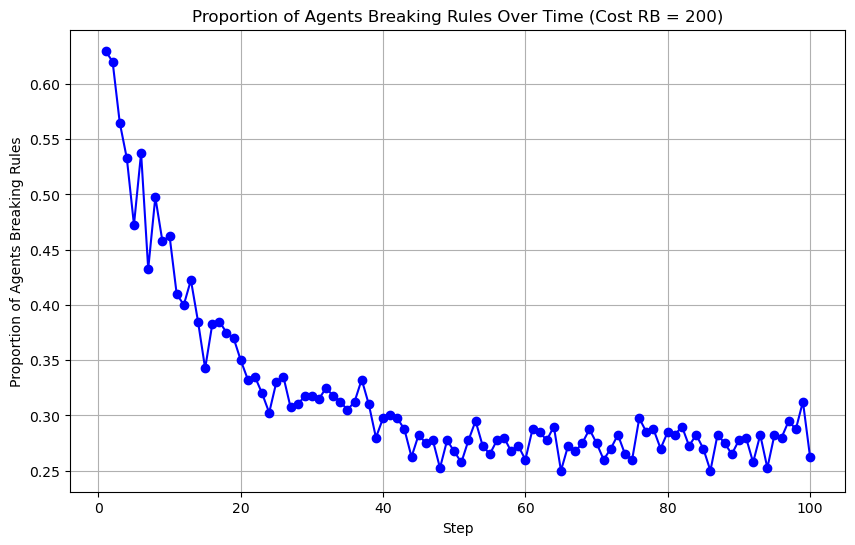

In [140]:
# Analyze results for the cost of rule-breaking when it's 200
results_200 = results_df[results_df["cost_rb"] == 200]

# Look at the proportion of agents who break the rules over time
proportion_crime = results_200.groupby("Step").mean()["Proportion crime"]
# Plot the proportion of agents who break the rules over time
plt.figure(figsize=(10, 6))
plt.plot(proportion_crime.index, proportion_crime.values, marker='o', linestyle='-', color='b')
plt.title("Proportion of Agents Breaking Rules Over Time (Cost RB = 200)")
plt.xlabel("Step")
plt.ylabel("Proportion of Agents Breaking Rules")
plt.grid()
plt.show()


In [42]:
# Calculate the Gini coefficient for the population
def gini_coefficient(wealths):
    """Calculate the Gini coefficient of a list of wealth values."""
    n = len(wealths)
    if n == 0:
        return 0
    sorted_wealths = np.sort(wealths)
    cumulative_wealths = np.cumsum(sorted_wealths)
    total_wealth = cumulative_wealths[-1]
    if total_wealth == 0:
        return 0
    gini_index = (2 * np.sum((np.arange(1, n + 1) * sorted_wealths))) / (n * total_wealth) - (n + 1) / n
    return gini_index
gini = gini_coefficient(results_df["Wealth End"])
print(f"Gini Coefficient: {gini}")


Gini Coefficient: 0.5888088805956069


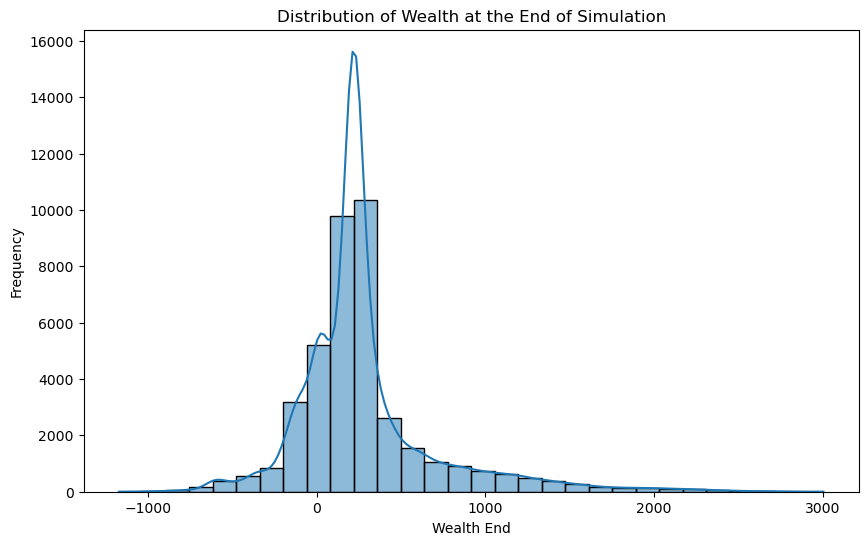

In [141]:
# Show distribution of wealth at the end of the simulation
plt.figure(figsize=(10, 6))
sns.histplot(results_df["Wealth End"], bins=30, kde=True)
plt.title("Distribution of Wealth at the End of Simulation")
plt.xlabel("Wealth End")
plt.ylabel("Frequency")
plt.show()


Text(0.5, 1.0, 'Wealth vs. Rule-breaking Behavior')

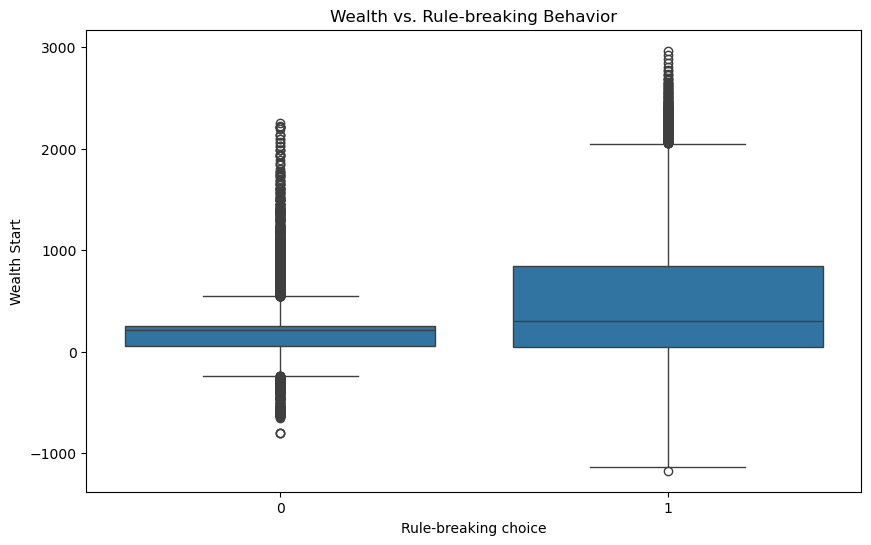

In [142]:
# Show relationship between wealth and rule-breaking behavior
plt.figure(figsize=(10, 6))
sns.boxplot(x="Rule-breaking choice", y="Wealth Start", data=results_df)
plt.title("Wealth vs. Rule-breaking Behavior")      


Text(0, 0.5, 'Income Rank')

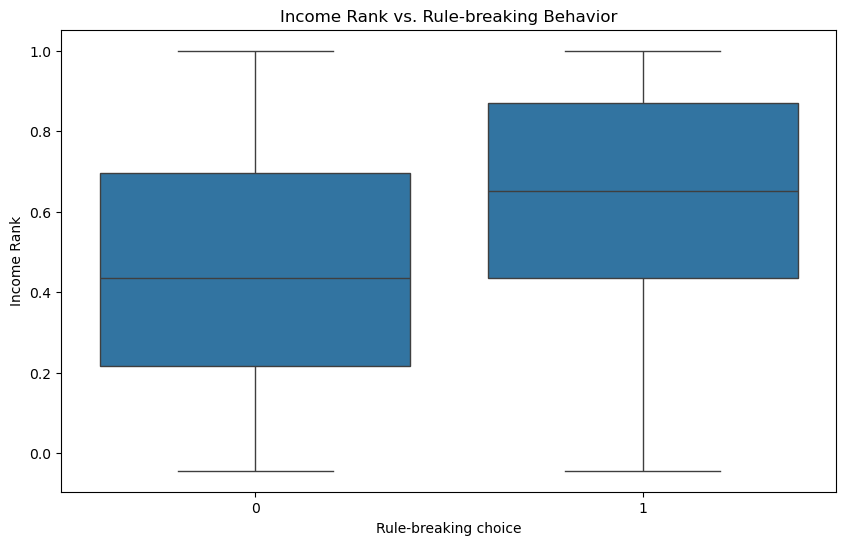

In [54]:
# Show the relationship between income rank and rule-breaking behavior
plt.figure(figsize=(10, 6))
sns.boxplot(x="Rule-breaking choice", y="income rank", data=results_df)
plt.title("Income Rank vs. Rule-breaking Behavior")
plt.xlabel("Rule-breaking choice")
plt.ylabel("Income Rank")

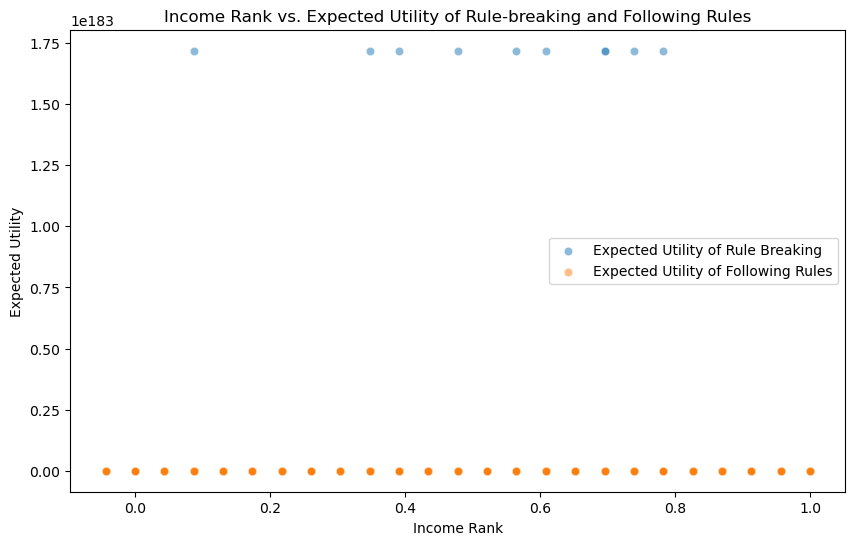

In [55]:
# Show the relationship between income rank and the expected utility of rule-breaking and following rules
plt.figure(figsize=(10, 6))
sns.scatterplot(x="income rank", y="SV_rule_break", data=results_df, alpha=0.5, label="Expected Utility of Rule Breaking")
sns.scatterplot(x="income rank", y="SV_follow_rules", data=results_df, alpha=0.5, label="Expected Utility of Following Rules")
plt.title("Income Rank vs. Expected Utility of Rule-breaking and Following Rules")
plt.xlabel("Income Rank")
plt.ylabel("Expected Utility")
plt.legend()
plt.show()

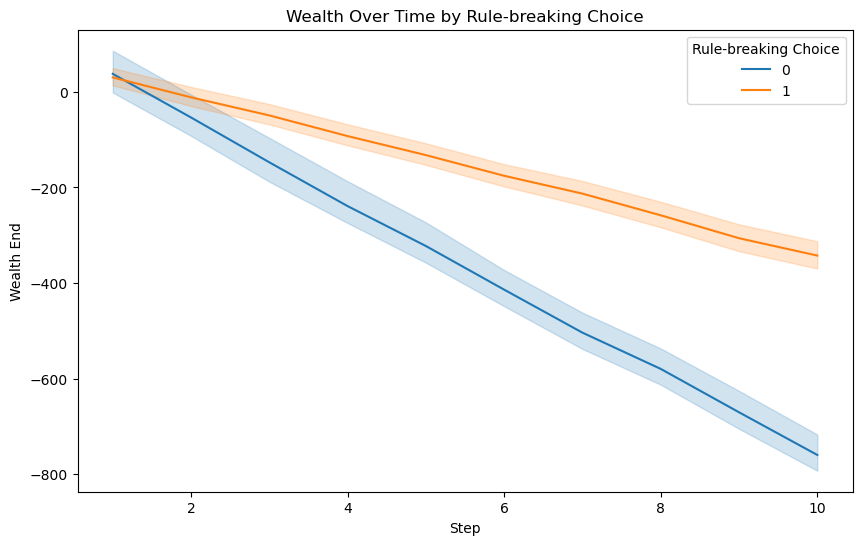

In [56]:
# Visualizing how agent wealth changes over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x="Step", y="Wealth End", hue="Rule-breaking choice")
plt.title("Wealth Over Time by Rule-breaking Choice")
plt.xlabel("Step")
plt.ylabel("Wealth End")
plt.legend(title="Rule-breaking Choice", loc='upper right')
plt.show()

## Wealth over time
https://mesa.readthedocs.io/stable/tutorials/intro_tutorial.html#collecting-data

In [ ]:
# Plot Gini coefficient over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x="Step", y="Gini coefficient", hue="Rule-breaking choice")
plt.title("Gini Coefficient Over Time by Rule-breaking Choice")
plt.xlabel("Step")
plt.ylabel("Wealth End")
plt.legend(title="Rule-breaking Choice", loc='upper right')
plt.show()

Text(0.5, 1.0, 'Wealth Over Time by Agent')

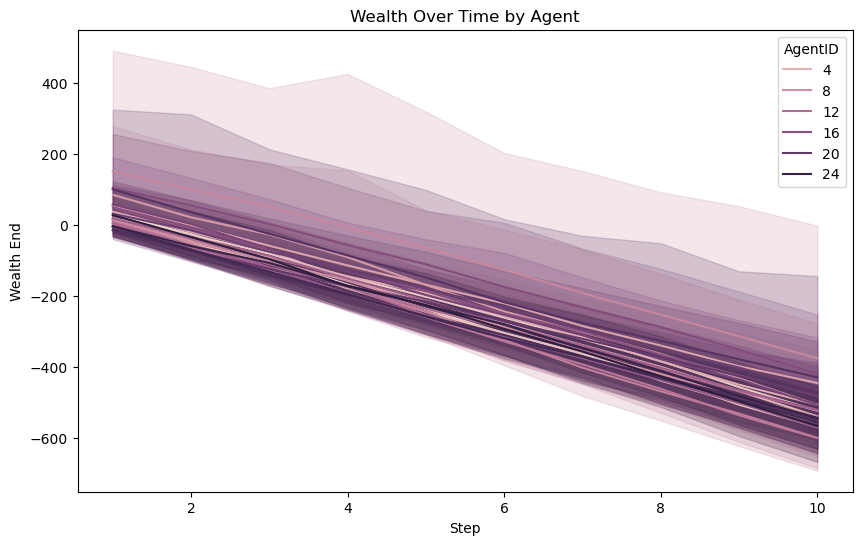

In [95]:
# Plot each agent's wealth over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x="Step", y="Wealth End", hue="AgentID")
plt.title("Wealth Over Time by Agent")

In [68]:
agent_wealth = test_model.datacollector.get_agent_vars_dataframe()
agent_wealth.head()

Wealth Start  Wealth End  income rank  desperate_state  \
Step AgentID                                                           
0    1           15.120797   15.120797          0.0                0   
     2           33.388709   33.388709          0.0                0   
     3          422.568258  422.568258          0.0                0   
     4           11.783694   11.783694          0.0                0   
     5          103.715918  103.715918          0.0                0   

              Rule-breaking choice  Caught  SV_rule_break  SV_follow_rules  
Step AgentID                                                                
0    1                           0   False            NaN              NaN  
     2                           0   False            NaN              NaN  
     3                           0   False            NaN              NaN  
     4                           0   False            NaN              NaN  
     5                           0   False            NaN              NaN

In [60]:
agent_wealth = test_model.datacollector.get_agent_vars_dataframe()
agent_wealth.head()

# Distribution of wealth at the end of the simulation
last_step = end_wealth.index.get_level_values("Step").max()
end_wealth = end_wealth.xs(last_step, level="Step")["Wealth"]
# Create a histogram of wealth at the last step
g = sns.histplot(end_wealth, discrete=True)
g.set(
    title="Distribution of wealth at the end of simulation",
    xlabel="Wealth",
    ylabel="number of agents",
);

NameError: name 'end_wealth' is not defined

### Grid Visualization

In [59]:
import mesa
print(f"Mesa version: {mesa.__version__}")

from mesa.visualization import SolaraViz, make_plot_component, make_space_component

Mesa version: 3.2.0


In [ ]:
def agent_portrayal(agent):
    return {
        "color": "tab:blue",
        "size": 50,
    }

In [60]:
model_params = {
    "n": {
        "type": "SliderInt",
        "value": 50,
        "label": "Number of agents:",
        "min": 10,
        "max": 100,
        "step": 1,
    },
    "width": 10,
    "height": 10,
}

## Stochastic Dynamic Programming

In [ ]:
# Using stochastic dynamic programming to find the optimal set of decisions/strategy for agents 
# given their starting wealth and psychological parameters
import cognitive_functions as cf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import multiprocessing
from joblib import Parallel, delayed
import time
import pickle
import os
import hashlib
import json
import scipy.stats as stats
from scipy.stats import t # For t-distribution
from scipy.stats import bernoulli
from scipy.special import softmax
from tqdm import tqdm
from collections import namedtuple
